In [35]:
# Parameters
param1=1

In [36]:
import torch
import numpy as np
from copy import deepcopy
import pickle as pkl

from torch import nn
from umap import UMAP

from run_sim import Config, run_sim, run_sim_wrapper, create_data
from utils import *
from utils_plot import *
from tqdm import tqdm
from utils import *
from functools import reduce
import os
from joblib import Parallel, delayed
import shutil


In [37]:
def calc_h_var(G, D, N, L, sig_X):
    return G**(2*L)*(2*D*sig_X)/(D+N)

In [38]:
C = Config()

C.G = 1
C.linear_net = False
C.learning_rate = 0.01
C.data_geometry = 'arm'
C.L=1
C.print_progress = True
C.length_corridors = [10]*1
C.max_move = 5
C.angle_range = np.pi/10
C.hidden_size = 100 # (C.length_corridors[0]+2*C.max_move+1 + 1)*len(C.length_corridors)
C.num_epochs = 10000
C.num_samples = 10000
C.algo_name = 'SGD'
C.loss_fn = nn.MSELoss()

var_name = 'max_move'
var_values = np.arange(1, 6)

In [ ]:


# Ensure the results directory exists
results_dir = f'results/notebook_results/{var_name}'
if os.path.exists(results_dir):
    shutil.rmtree(results_dir)
os.makedirs(results_dir, exist_ok=True)

def run_and_save(var_value):
    C_local = deepcopy(C)
    setattr(C_local, var_name, var_value)
    data_dict = run_sim_wrapper(C_local)
    out_path = os.path.join(results_dir, f'data_dict_{getattr(C_local, var_name)}.pkl')
    with open(out_path, 'wb') as f:
        pkl.dump(data_dict, f)
    return out_path

# Run in parallel
paths = Parallel(n_jobs=-1)(
    delayed(run_and_save)(var_value) for var_value in var_values
)
# Load all results into data_dict_l
data_dict_l = []
for path in paths:
    with open(path, 'rb') as f:
        data_dict_l.append(pkl.load(f))

for data_dict in data_dict_l:
    print(f'{var_name}: {getattr(data_dict["C"], var_name)} --- X shape: {data_dict["X"].shape} --- Number of hidden: {data_dict["C"].hidden_size}')

In [ ]:
def plot_pca(data_dict, title="", axs=None):
    loc_y = data_dict['loc_y']
    hidden_states = data_dict['hidden_states']
    action_taken = data_dict['action_taken']
    loss_l = data_dict['loss_l']; accuracy_l = data_dict['accuracy_l']
    y = data_dict['y'].cpu().numpy()
    C = data_dict['C']
    corridor = data_dict['corridor']
    X_np = data_dict['X'].cpu().numpy()
    final_weights = data_dict['final_weights']

    colors = action_taken[:,0]

    hidden = hidden_states[-1].cpu().detach().numpy()

    PR = calc_PR(hidden)
    if not C.bias:
        W_effective = get_effective_W_from_model_dict(final_weights).cpu().numpy()
        W_PR = calc_PR(W_effective)
        if C.L == 0:
            U, S, V = np.linalg.svd(W_effective, full_matrices=False)
            hidden = X_np @ U @ np.diag(S)
    else:
        W_PR = 0
    hidden_pr = calc_PR(hidden)
    
    # alignment = alignment_score(hidden[corridor==0], hidden[corridor==1]) if n_corridors > 1 else 0
    order = get_r_2(PCA(n_components=1).fit_transform(hidden), colors)

    pca = PCA().fit(hidden)
    X_reduced = pca.transform(hidden)
    if axs is None:
        fig, axs = plt.subplots(1, 5, figsize=(25/2, 5/2))
        axs[0].set_ylabel(title)
    # Add cumulative explained variance ratio in the first row
    ax1 = axs[0]
    ax1.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
    ax1.set_xlabel('Number of Components')
    # ax1.set_ylabel('Cumulative EVR')
    ax1.set_title(f'order = {order:.2f} --- W PR = {W_PR:.2f} --- hidden PR = {hidden_pr:.2f}')
    ax1.set_ylim(-0.1, 1.1)
    
    ax1 = axs[1]
    for cor, marker in zip(np.unique(corridor), markers):
        ax1.scatter(X_reduced[corridor==cor, 0], X_reduced[corridor==cor, 1], c=colors[corridor==cor], cmap='coolwarm', alpha=0.7, marker=marker)
    ax1.set_xlabel(f'Component 1')
    ax1.set_ylabel(f'Component 2'),
    ax1.axis('equal')
    
    ax1 = axs[2]
    for cor, marker in zip(np.unique(corridor), markers):
        ax1.scatter(X_reduced[corridor==cor, 0], X_reduced[corridor==cor, 1], c=loc_y[:,0][corridor==cor], cmap='coolwarm', alpha=0.7, marker=marker)
    ax1.set_xlabel(f'Component 1')
    ax1.set_ylabel(f'Component 2'),
    ax1.axis('equal')

    ax1 = axs[3]
    ax1.scatter(X_reduced[:, 0], colors, c=colors)

    axs[4].plot(loss_l)
    axs[4].set_yscale('log')
    ax2 = axs[4].twinx()
    ax2.plot(accuracy_l, 'r')
    ax2.set_ylim(-0.1, 1.1)
    axs[4].set_title("Loss")

    plt.tight_layout()

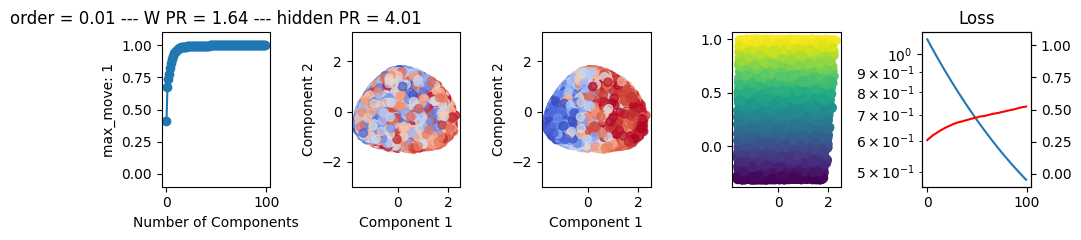

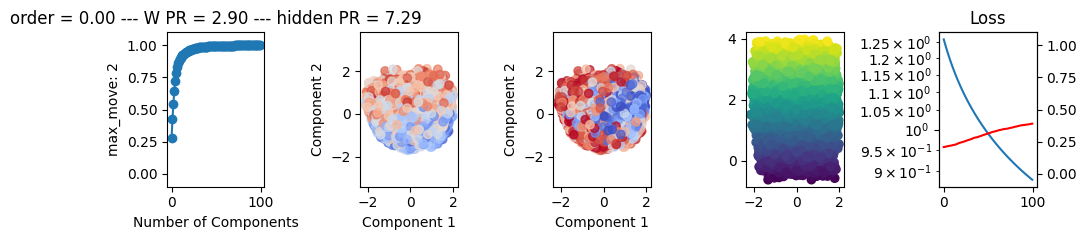

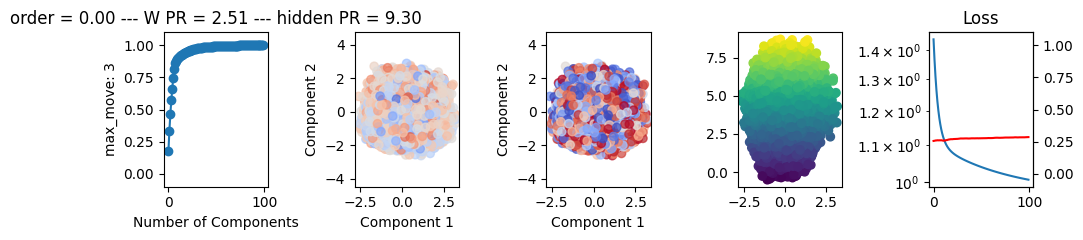

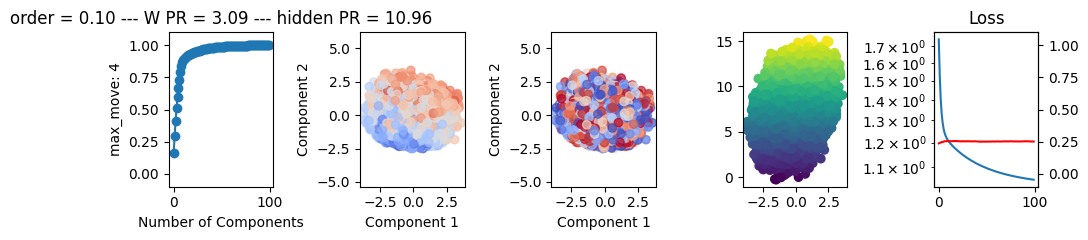

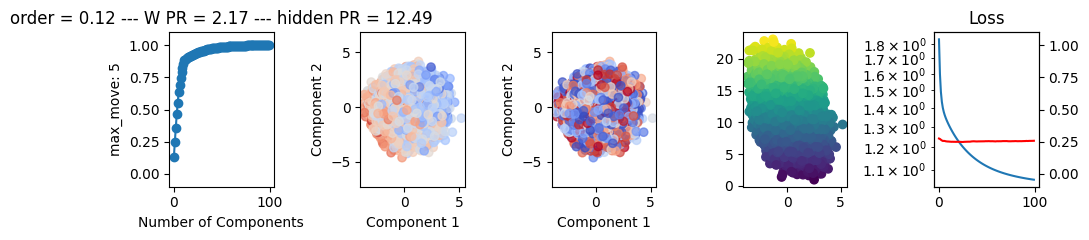

In [ ]:
for data_dict in data_dict_l:
    plot_pca(data_dict, title=f'{var_name}: {getattr(data_dict["C"], var_name)}')